In [4]:
import os
import sys
sys.path.append(os.path.abspath(".."))

In [ ]:
from src.Data_preprocessing import load_data
df=load_data()

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr,spearmanr

___

<p style="color:red;font-size:40px">1- target Analysis

## target Analysis

In [7]:
df["charges"].head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

 Machine Learning Problem

This dataset is used for **Supervised Machine Learning**, where the model learns from labeled data.

The target variable is **Charges**, representing the individual's medical insurance cost.

Since the target is a **continuous numerical value**, the task is a **Regression** problem.

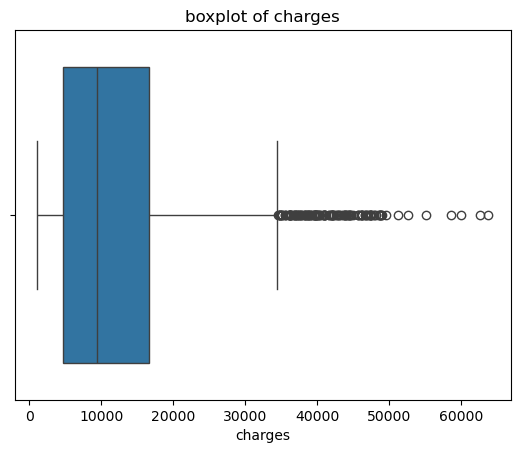

In [8]:
sns.boxplot(data=df,x=df["charges"])
plt.title("boxplot of charges")
plt.savefig("../Figures/boxplot of charges.png")

- These are not errors; rather, they are actual values ​​for a small number of cases involving individuals who may be smokers and elderly.

In [9]:
len(df["charges"].unique())

1337

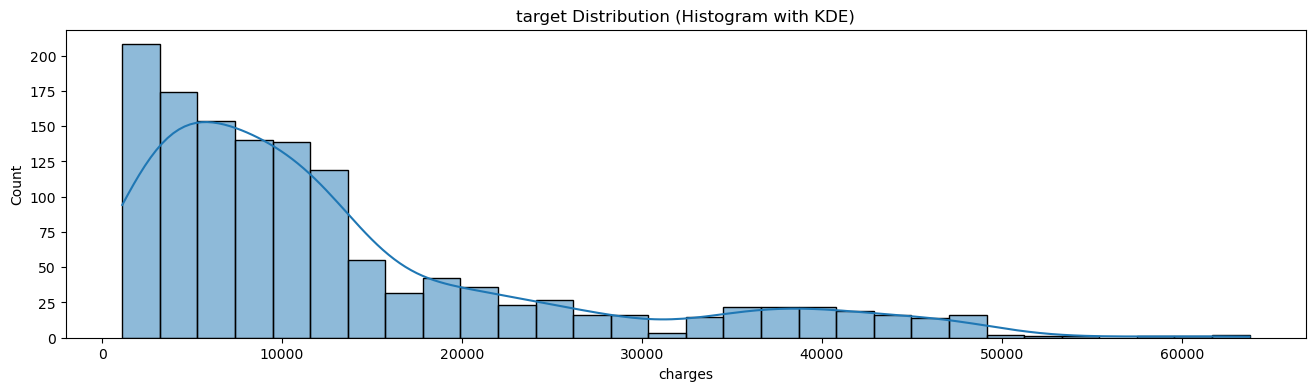

In [10]:
plt.figure(figsize=(16,4))
sns.histplot(
    data=df,
    x="charges",
    kde=True
)
plt.title("target Distribution (Histogram with KDE)")
plt.savefig("../Figures/charges[target] Distribution (Histogram with KDE.png")
plt.show()

- There are very few high-value costs; the **majority fall below 15,000**.

In [11]:
df["age"].mean()

39.20702541106129

In [12]:
df["charges"].median()

9382.033

In [13]:
df["charges"].skew()

1.5158796580240388

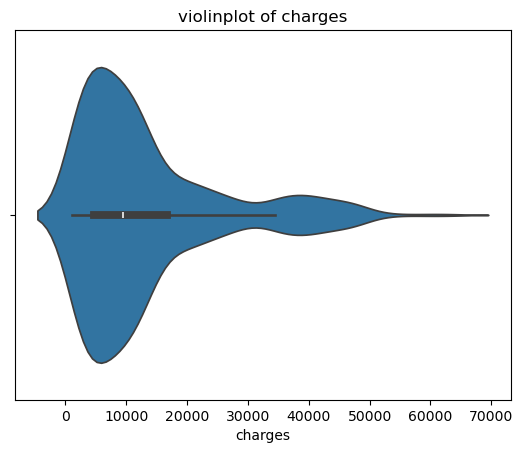

In [14]:
sns.violinplot(data=df,x=df["charges"])
plt.title("violinplot of charges")
plt.savefig("../Figures/violinplot of charges.png")

- **high right skew**

____

## 

___

<p style="color:red;font-size:40px">2-Univariant Analysis

### [1] Age


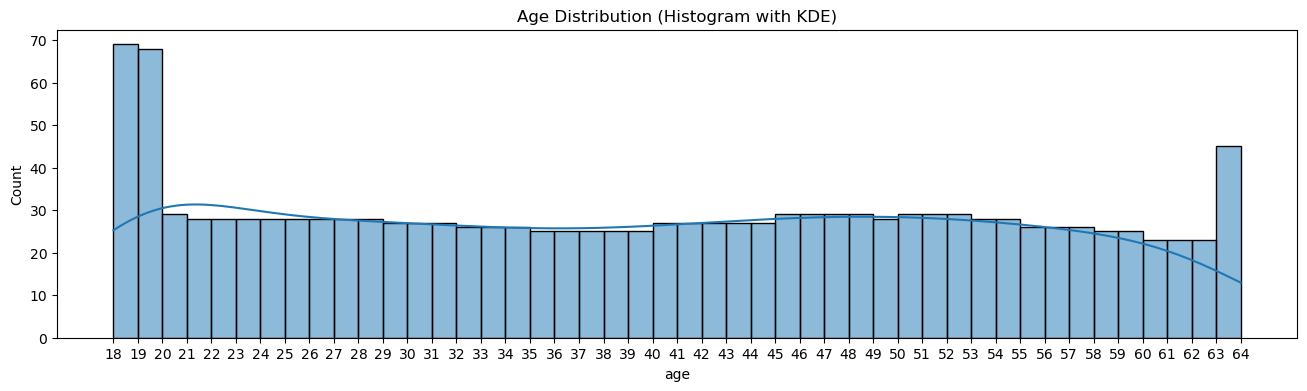

In [15]:
plt.figure(figsize=(16,4))
sns.histplot(
    data=df,
    x="age",
    binwidth=1,
    kde=True
)
plt.xticks(range(18, 65))
plt.title("Age Distribution (Histogram with KDE)")
plt.savefig("../Figures/Age Distribution (Histogram with KDE.png")
plt.show()



- The highest number of individuals is observed at **18 and 19 years of age**.
- After the early 20s, the number of individuals generally decreases.
- After that, at the 64 mark, they increased again.

In [16]:
df["age"].describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

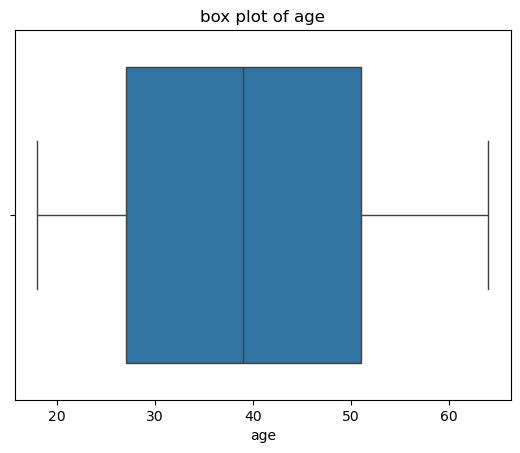

In [17]:
sns.boxplot(data=df,x="age")
plt.title("box plot of age")
plt.savefig("../Figures/boxplot of age.png")
plt.show()

### [2] bmi

In [18]:
len(df["bmi"].unique())

548

In [19]:
df["bmi"].describe()

count    1338.000000
mean       30.663397
std         6.098187
min        15.960000
25%        26.296250
50%        30.400000
75%        34.693750
max        53.130000
Name: bmi, dtype: float64

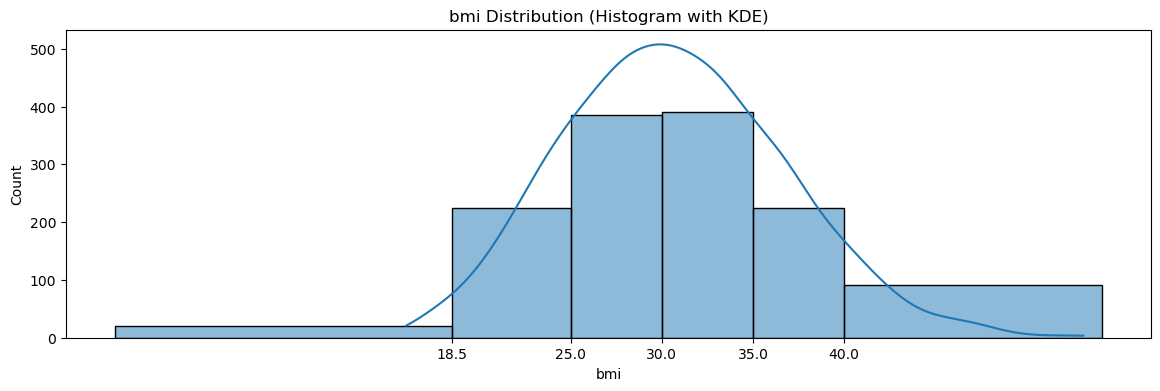

In [20]:
plt.figure(figsize=(14,4))
sns.histplot(
    data=df,
    x="bmi",
    bins=[0, 18.5, 25, 30, 35, 40, df["bmi"].max()+1],
    kde=True
)

plt.xticks([18.5, 25, 30, 35, 40])
plt.title("bmi Distribution (Histogram with KDE)")
plt.savefig("../Figures/bmi Distribution (Histogram with KDE.png")
plt.show()


**BMI Categories Overview**
| Category | BMI Range |
| :--- | :--- |
| **Underweight** | $< 18.5$ |
| **Normal / Healthy Weight** | $18.5 - 24.9$ |
| **Overweight** | $25.0 - 29.9$ |
| **Obesity (Class I)** | $30.0 - 34.9$ |
| **Obesity (Class II)** | $35.0 - 39.9$ |
| **Extreme / Severe Obesity (Class III)** | $\ge 40.0$ |



- most of people in **overweight and obesity class 1**
- less in underweight
- number not large and not small in Extreme

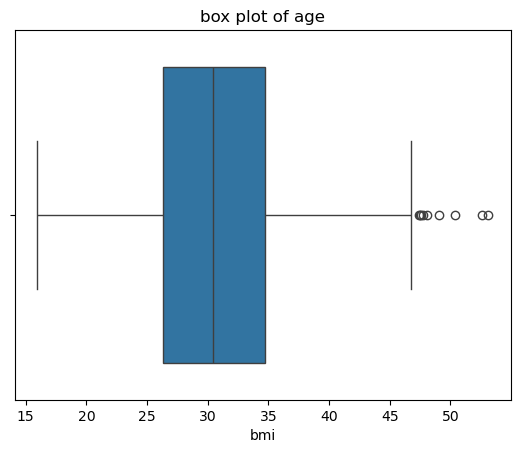

In [21]:
sns.boxplot(data=df,x="bmi")
plt.title("box plot of age")
plt.savefig("../Figures/boxplot of bmi.png")
plt.show()

### [3] sex

In [22]:
df["sex"].unique()

array(['female', 'male'], dtype=object)

In [23]:
df["sex"].nunique() #categories

2

In [24]:
df["sex"].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [25]:
df["sex"].value_counts(normalize=True)

sex
male      0.505232
female    0.494768
Name: proportion, dtype: float64


- The numbers and percentages are close to one another.

<function matplotlib.pyplot.show(close=None, block=None)>

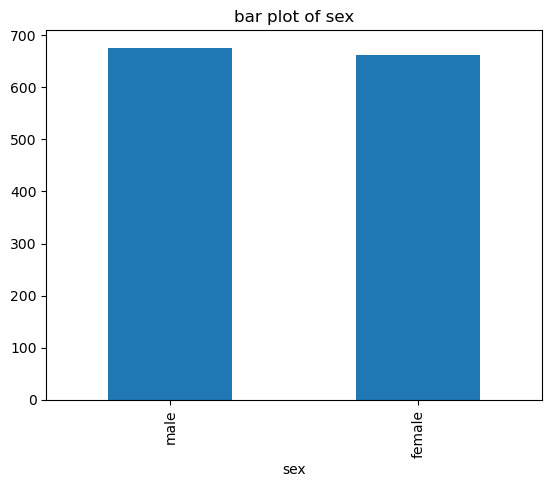

In [26]:
df["sex"].value_counts().plot(kind="bar")
plt.title("bar plot of sex")
plt.savefig("../Figures/bar plot of sex.png")
plt.show


### [4]children

<function matplotlib.pyplot.show(close=None, block=None)>

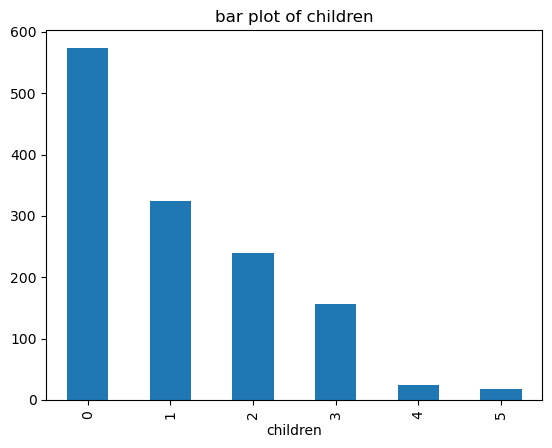

In [27]:
df["children"].value_counts().plot(kind="bar")
plt.title("bar plot of children")
plt.savefig("../Figures/bar plot of children.png")
plt.show

In [28]:
df["children"].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64


- The more children there are, the fewer people there are.

## [5] region

<function matplotlib.pyplot.show(close=None, block=None)>

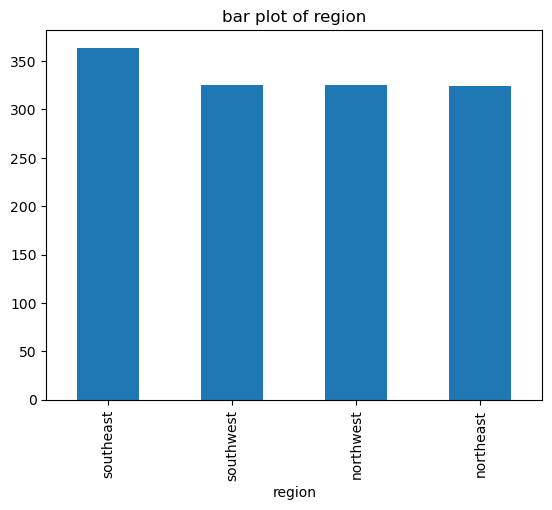

In [29]:
df["region"].value_counts().plot(kind="bar")
plt.title("bar plot of region")
plt.savefig("../Figures/bar plot of region.png")
plt.show

In [30]:
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


- The numbers are very close, but the South has a larger number.

## [6] Smoker

<function matplotlib.pyplot.show(close=None, block=None)>

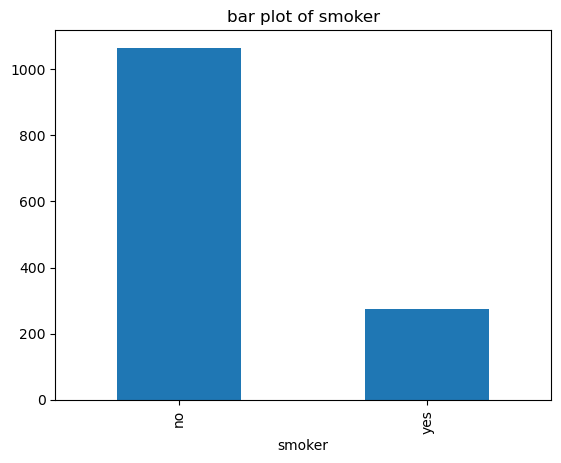

In [31]:
df["smoker"].value_counts().plot(kind="bar")
plt.title("bar plot of smoker")
plt.savefig("../Figures/bar plot of smoker.png")
plt.show

In [32]:
df["smoker"].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64


- The number of non-smokers is far greater than that of smokers.

##

___

<p style="color:red;font-size:40px">3- bivariant analysis

### age & charges

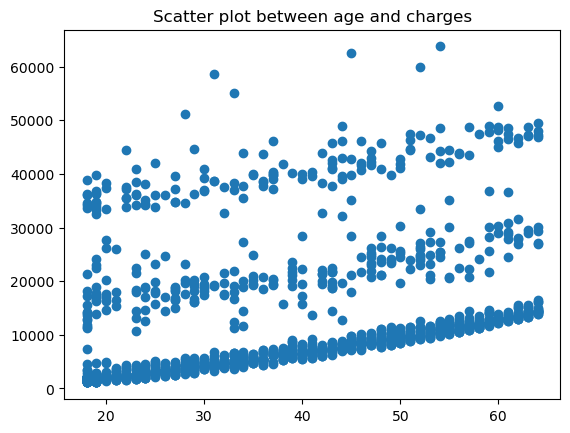

In [33]:
plt.scatter(df["age"],df["charges"])
plt.title("Scatter plot between age and charges")
plt.savefig("../Figures/Scatter plot between age and charges.png")
plt.show()

In [34]:
corr,p_value=spearmanr(df["age"],df["charges"])
print(corr)
print(p_value)

0.5343921337718459
1.130692027803638e-99


- Spearman's reliability is better if the relationship is Moderate positive

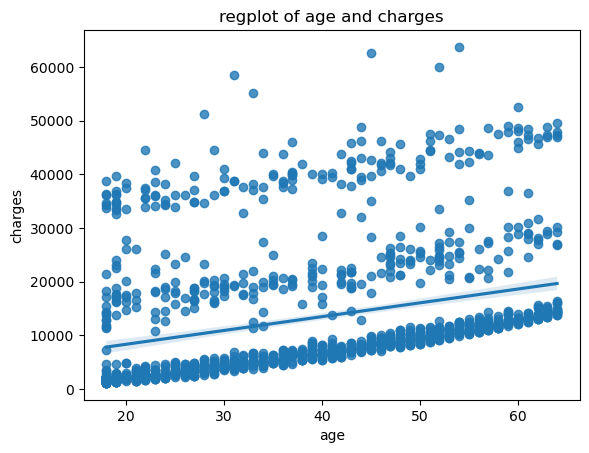

In [35]:
sns.regplot(data=df,x=df["age"],y=df["charges"])
plt.title("regplot of age and charges")
plt.savefig("../Figures/regplot of age and charges.png")

- Not all data points lie close to the line, but the line tends toward the area containing the highest concentration of data; therefore, the relationship is positive, though not strong.

### bmi & charges

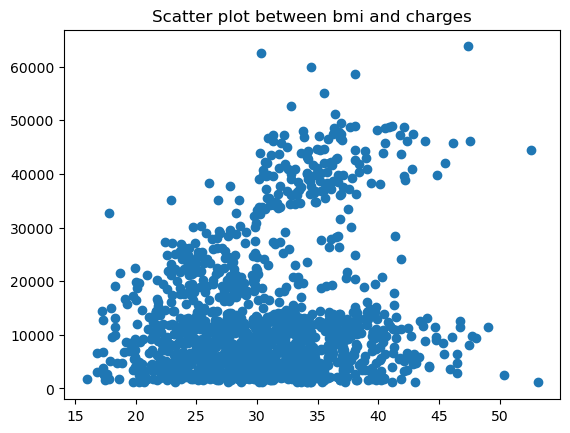

In [36]:
plt.scatter(df["bmi"],df["charges"])
plt.title("Scatter plot between bmi and charges")
plt.savefig("../Figures/Scatter plot between bmi and charges.png")
plt.show()

- We observe that as the BMI increases, the cost rises, reaching high extreme costs.

In [37]:
corr,p_value=spearmanr(df["bmi"],df["charges"])
print(corr)
print(p_value)

0.11939590358331145
1.1926059544526874e-05


- very weak positive

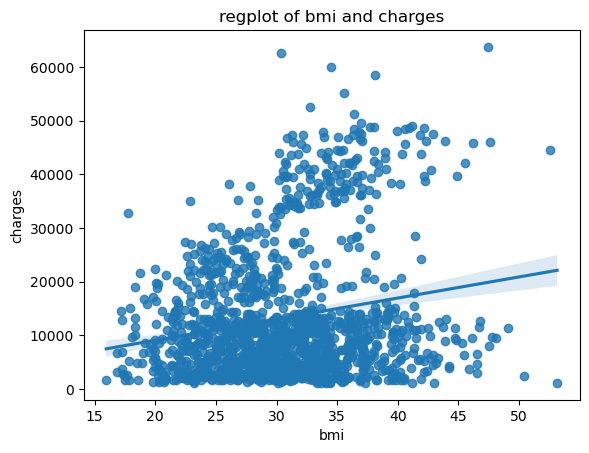

In [38]:
sns.regplot(data=df,x=df["bmi"],y=df["charges"])
plt.title("regplot of bmi and charges")
plt.savefig("../Figures/regplot of bmi and charges.png")

- The line passes through few points, indicating a weak relationship.

### age & bmi

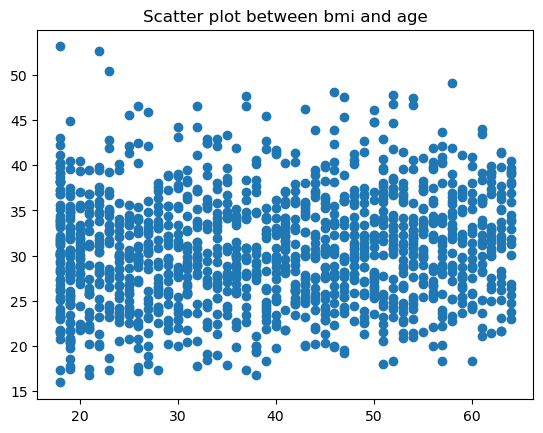

In [39]:
plt.scatter(df["age"],df["bmi"])
plt.savefig("../Figures/Scatter plot between bmi and age.png")
plt.title("Scatter plot between bmi and age")
plt.show()

- There is no obvious trend between age and BMI. The data points are scattered randomly, suggesting a weak or negligible correlation between the two variables.

### bmi & region and bmi & smoker

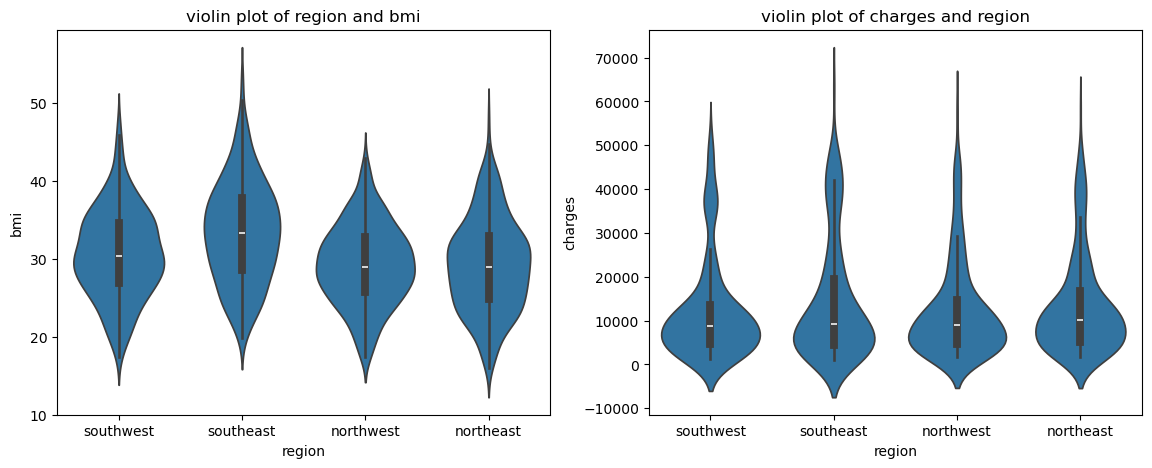

In [40]:
fig,ax=plt.subplots(1,2,figsize=(14,5))
sns.violinplot(
    data=df,
    x=df["region"],
    y=df["bmi"],
    ax=ax[0]
)
ax[0].set_title("violin plot of region and bmi")

sns.violinplot(
    data=df,
    x=df["region"],
    y=df["charges"],
    ax=ax[1]
)
ax[1].set_title("violin plot of charges and region")

plt.savefig("../Figures/violin plot to region with bmi and charges.png")
plt.show()


- In the **southeast, the BMI is at a high level**.
- Consequently, we observe that the costs in it involved are high, reaching [70000] significant levels.

- most of people thier bmi in range 25 and 35 [overweight and obesity class 1] in all regions


### charges & smoker

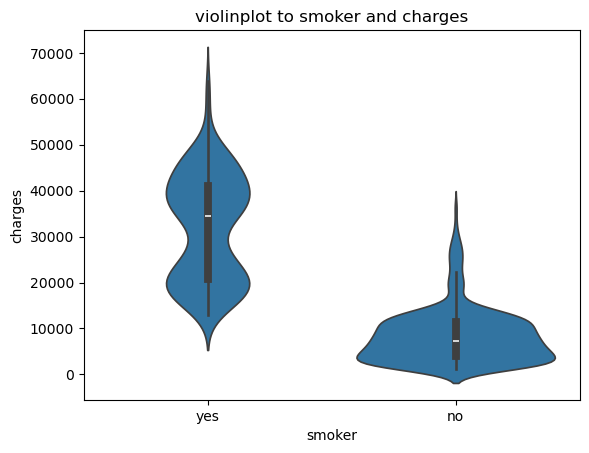

In [41]:
sns.violinplot(data=df,x=df["smoker"],y=df["charges"])
plt.title("violinplot to smoker and charges")
plt.savefig("../Figures/violinplot to smoker and charges.png")
plt.show()

- It is clearly noticeable that **smokers pay much more than non-smokers**.
- The number of **smokers** paying in the range of around 30,000 is small compared to the rest of the costs.
- For a great **many non-smokers, the cost is mostly under 20,000** [it's high righ skew] ,After that, a very small number of them pay costs reaching up to 40,000—possibly due to having a larger number of children or because of obesity.


### charges & sex and charges & children

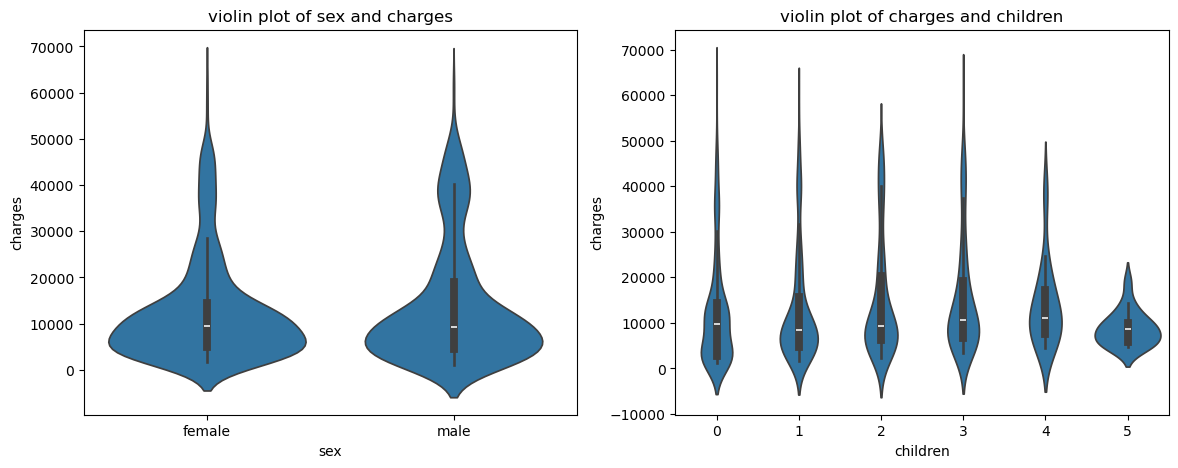

In [42]:
fig,ax=plt.subplots(1,2,figsize=(14,5))
sns.violinplot(
    data=df,
    x=df["sex"],
    y=df["charges"],
    ax=ax[0]
)
ax[0].set_title("violin plot of sex and charges")

sns.violinplot(
    data=df,
    x=df["children"],
    y=df["charges"],
    ax=ax[1]
)
ax[1].set_title("violin plot of charges and children")

plt.savefig("../Figures/violin plot to sex and children with charges.png")
plt.show()


- There are people who have afew children—a situation that often entails high costs—and this is frequently due to smoking and obesity.

- In contrast, people with more children often pay less; this may be due to the local area—where hospitals might be standard and inexpensive—as well as factors related to BMI and obesity.

- We already know that the majority of people fall into the under-20,000 cost bracket, but we have now learned that the largest group among them is women.

### smoker with sex and region

In [43]:
pd.crosstab(
    df["region"],
    df["smoker"],
    normalize="index"
)

smoker,no,yes
region,,
northeast,0.793210,0.206790
northwest,0.821538,0.178462
southeast,0.750000,0.250000
southwest,0.821538,0.178462


- The Southeast is the region where the highest number of people smoke; consequently, costs there are the highest.

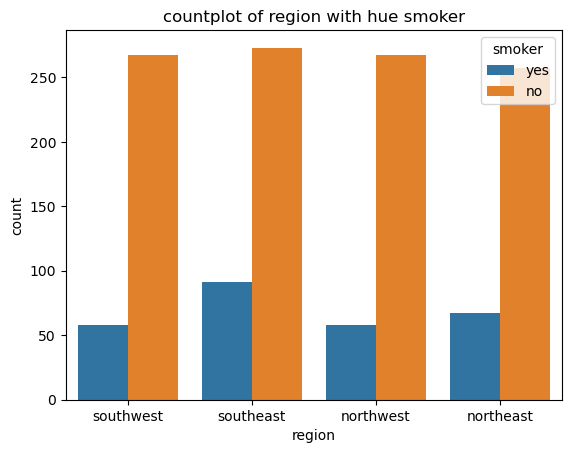

In [44]:
sns.countplot(
    data=df,
    x="region",
    hue="smoker"
)
plt.title("countplot of region with hue smoker")
plt.savefig("../Figures/countplot of region with hue smoker.png")
plt.show()

In [45]:
pd.crosstab(
    df["sex"],
    df["smoker"],
    normalize="index"
)


smoker,no,yes
sex,,
female,0.826284,0.173716
male,0.764793,0.235207


- The majority of smokers are men, and consequently, they incur higher costs; however, it is worth noting that costs for women rise at a certain age due to factors such as childbirth and related issues.

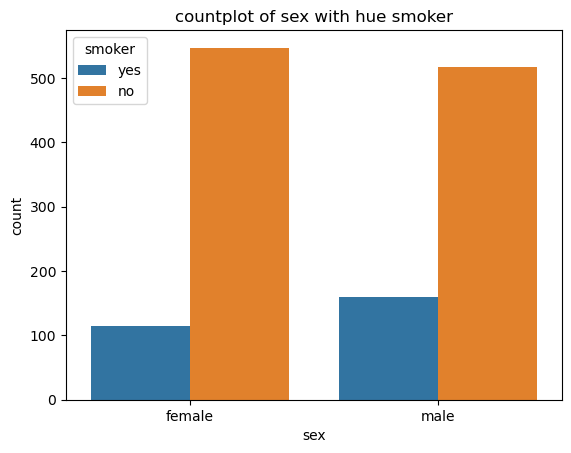

In [46]:
sns.countplot(
    data=df,
    x="sex",
    hue="smoker"
)
plt.title("countplot of sex with hue smoker")
plt.savefig("../Figures/countplot of sex with hue smoker.png")
plt.show()

###

___